<a href="https://colab.research.google.com/github/CD-GRUPO3/TA047R-1C2025-GRUPO03/blob/main/TA047R_TP1_GRUPO03_ENTREGA_EJ4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo 3 - Ejercicio 4: *Agrupamiento (Clustering)*
**Objetivo:** analizar si es posible agrupar los datos de un conjunto de datos que contiene información sobre algunos tracks (canciones) de Spotify, en función de algún criterio, mediante el algoritmo K-Means.


**Integrantes:**
- ARIAS, Rafaela Pilar. 112272. rparias@fi.uba.ar.
- BARCALA ROCA, Ramiro. 112478. rbarcala@fi.uba.ar.
- LEMA, Mora. 111831. molema@fi.uba.ar.
- IENCO, Lara Eliana. 111921. lienco@fi.uba.ar.
___

####Bibliografía:


##Inicialización del entorno

In [57]:
import pandas as pd #Manipulación y análisis de datos
import seaborn as sns
import matplotlib.pyplot as plt
!pip install tabulate
from tabulate import tabulate

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans

from sklearn.manifold import TSNE

from sklearn.decomposition import PCA

In [58]:
!gdown 1hUQM0DIbP41STW2Mhk5_zk1fpYD0y4I_

Downloading...
From: https://drive.google.com/uc?id=1hUQM0DIbP41STW2Mhk5_zk1fpYD0y4I_
To: /content/playlist_spotify.csv
100% 54.4k/54.4k [00:00<00:00, 55.1MB/s]


##Análisis exploratorio

In [59]:
data =pd.read_csv('playlist_spotify.csv')

In [60]:
shape = data.shape
print("Filas: %d\nColumnas: %d" % (shape[0], shape[1]))

Filas: 750
Columnas: 13


In [61]:
data

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,0.713000,0.514,100125,0.521,0.816000,8,0.1120,-14.835,0,0.0444,119.879,4,0.143
1,0.192000,0.714,207019,0.614,0.000000,4,0.2630,-6.935,1,0.0319,123.969,4,0.582
2,0.333000,0.630,216200,0.455,0.000004,5,0.1270,-9.290,1,0.0292,139.931,4,0.199
3,0.601000,0.810,136413,0.221,0.210000,5,0.1840,-11.005,1,0.0429,109.960,4,0.798
4,0.883000,0.465,181440,0.459,0.000173,6,0.0692,-8.137,0,0.0351,90.807,4,0.288
...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,0.000175,0.374,333827,0.943,0.000156,6,0.1250,-4.108,0,0.0556,112.084,4,0.338
746,0.001970,0.487,213000,0.867,0.006020,10,0.0968,-3.293,0,0.0543,160.048,4,0.403
747,0.916000,0.605,125867,0.314,0.000000,0,0.3590,-7.631,1,0.0327,138.148,4,0.836
748,0.168000,0.700,249493,0.823,0.000028,3,0.1220,-6.892,1,0.0373,144.060,4,0.745


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      750 non-null    float64
 1   danceability      750 non-null    float64
 2   duration          750 non-null    int64  
 3   energy            750 non-null    float64
 4   instrumentalness  750 non-null    float64
 5   key               750 non-null    int64  
 6   liveness          750 non-null    float64
 7   loudness          750 non-null    float64
 8   mode              750 non-null    int64  
 9   speechiness       750 non-null    float64
 10  tempo             750 non-null    float64
 11  time_signature    750 non-null    int64  
 12  valence           750 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 76.3 KB


| Variable           | Descripción |
|--------------------|-------------|
| `acousticness`     | Medida de confianza sobre si la pista es acústica. Valores entre 0.0 y 1.0. |
| `danceability`     | Qué tan adecuada es la pista para bailar, según su ritmo, tempo, estabilidad, etc. |
| `duration`     | Duración de la pista en milisegundos. |
| `energy`           | Nivel de intensidad y actividad percibida en la pista. Entre 0.0 y 1.0. |
| `instrumentalness` | Predice si la pista no tiene voces. Valores cercanos a 1.0 indican que es instrumental. |
| `key`              | Tono en el que está la canción, como número entero (por ejemplo, 0 = C, 1 = C#/Db, etc.). -1 si no se detecta. |
| `liveness`         | Estima si hay presencia de público. Valores altos indican que puede ser una grabación en vivo. |
| `loudness`         | Volumen promedio de la pista en decibelios (dB). Normalmente valores negativos. |
| `mode`             | Modalidad de la escala: 1 es mayor, 0 es menor. |
| `speechiness`      | Mide la presencia de palabras habladas. Más cerca de 1.0 = más hablada. |
| `tempo`            | Tempo estimado de la pista en BPM (pulsos por minuto). |
| `time_signature`   | Número estimado de tiempos por compás. |
| `valence`          | Qué tan positiva o alegre suena la pista. Valores altos = más feliz. |


###**Análisis de las variables**
Podemos analizar las variables clasificándolas como:

- **Cuantitativas (numéricas):** continuas y discretas.

- **Cualitativas (categóricas):** nominales y ordinales.

**CUANTITATIVAS:**

**CONTINUAS**

- **acousticness:** Medida de confianza sobre si la pista es acústica. Valores entre 0.0 y 1.0.
- **danceability:** Qué tan adecuada es la pista para bailar, según su ritmo, tempo, estabilidad, etc.
- **duration:** Duración de la pista en milisegundos.
- **energy:** Nivel de intensidad y actividad percibida en la pista. Entre 0.0 y 1.0.
- **instrumentalness:** Predice si la pista no tiene voces. Valores cercanos a 1.0 indican que es instrumental.
-**liveness:** Estima si hay presencia de público. Valores altos indican que puede ser una grabación en vivo.
- **loudness:** Volumen promedio de la pista en decibelios (dB). Normalmente valores negativos.
- **speechiness:** Mide la presencia de palabras habladas. Más cerca de 1.0 = más hablada.
- **tempo:** Tempo estimado de la pista en BPM (pulsos por minuto).
- **valence:** Qué tan positiva o alegre suena la pista. Valores altos = más feliz.

**DISCRETAS:**
- **time_signature:** Número estimado de tiempos por compás.

In [63]:
variables_cuantitativas = ['acousticness', 'danceability', 'duration', 'energy', 'instrumentalness', 'liveness', 'loudness',
                           'speechiness', 'tempo', 'valence', 'time_signature']


#Tomamos sus medidas de resumen
cuantitativas = data[variables_cuantitativas].describe()

#Calculamos la moda y la agregamos como fila ya que describe no la proporciona
moda = data[variables_cuantitativas].mode().iloc[0]
cuantitativas.loc['moda'] = moda

#Mostramos el DataFrame con display para que se vea como una tabla
display(cuantitativas.T)

,count,mean,std,min,25%,50%,75%,max,moda
acousticness,750.0,0.357394,0.338405,0.000001,0.03715,0.24450,0.678500,0.994,0.9920
danceability,750.0,0.596439,0.172036,0.107000,0.48000,0.60600,0.715750,0.986,0.5250
duration,750.0,220112.733333,65587.690483,33840.000000,185490.25000,215108.50000,244236.750000,675360.000,213440.0000
energy,750.0,0.594188,0.253301,0.009250,0.42325,0.63150,0.804750,0.995,0.6660
instrumentalness,750.0,0.100245,0.259921,0.000000,0.00000,0.00001,0.002245,0.967,0.0000
liveness,750.0,0.203376,0.177609,0.024000,0.09455,0.12900,0.264750,0.979,0.1020
loudness,750.0,-8.509339,5.039488,-29.601000,-10.17350,-7.27000,-5.097750,-0.533,-7.2730
speechiness,750.0,0.098966,0.104715,0.023400,0.03590,0.04875,0.113000,0.721,0.0349
tempo,750.0,120.405761,28.378116,55.747000,98.99800,120.10450,138.074750,204.162,89.0190
valence,750.0,0.497321,0.239615,0.033200,0.29700,0.48300,0.684500,0.975,0.1990


**CUALITATIVAS:**

**NOMINALES:**
- **mode:** (binaria) Modalidad de la escala: 1 es mayor, 0 es menor.


**ORDINALES:**
- **key:** Tono en el que está la canción, como número entero (por ejemplo, 0 = C, 1 = C#/Db, etc.). -1 si no se detecta.

In [64]:
variables_cualitativas = ['mode', 'key']
valores_unicos_lista = []

#Recorremos cada columna cualitativa y obtenemos sus valores únicos
for col in variables_cualitativas:
    valores_unicos = ", ".join(map(str, data[col].unique()))  #Convierte valores a string y une con ", "
    valores_unicos_lista.append(valores_unicos)

#Creamos un DataFrame con formato más limpio
data_cualitativas = pd.DataFrame({'Columna': variables_cualitativas, 'Valores Únicos': valores_unicos_lista})
display(data_cualitativas) #Mostrar la tabla

,Columna,Valores Únicos
0,mode,"0, 1"
1,key,"8, 4, 5, 6, 9, 1, 0, 2, 7, 11, 3, 10"


## Datos faltantes

In [65]:
print("Cantidad total de valores NaN en el dataset:", data.isnull().sum().sum())

Cantidad total de valores NaN en el dataset: 0


¡No hay datos faltantes en el dataset! Por lo que no es necesaraio aplicar técnicas de imputación.

## Valores atípicos

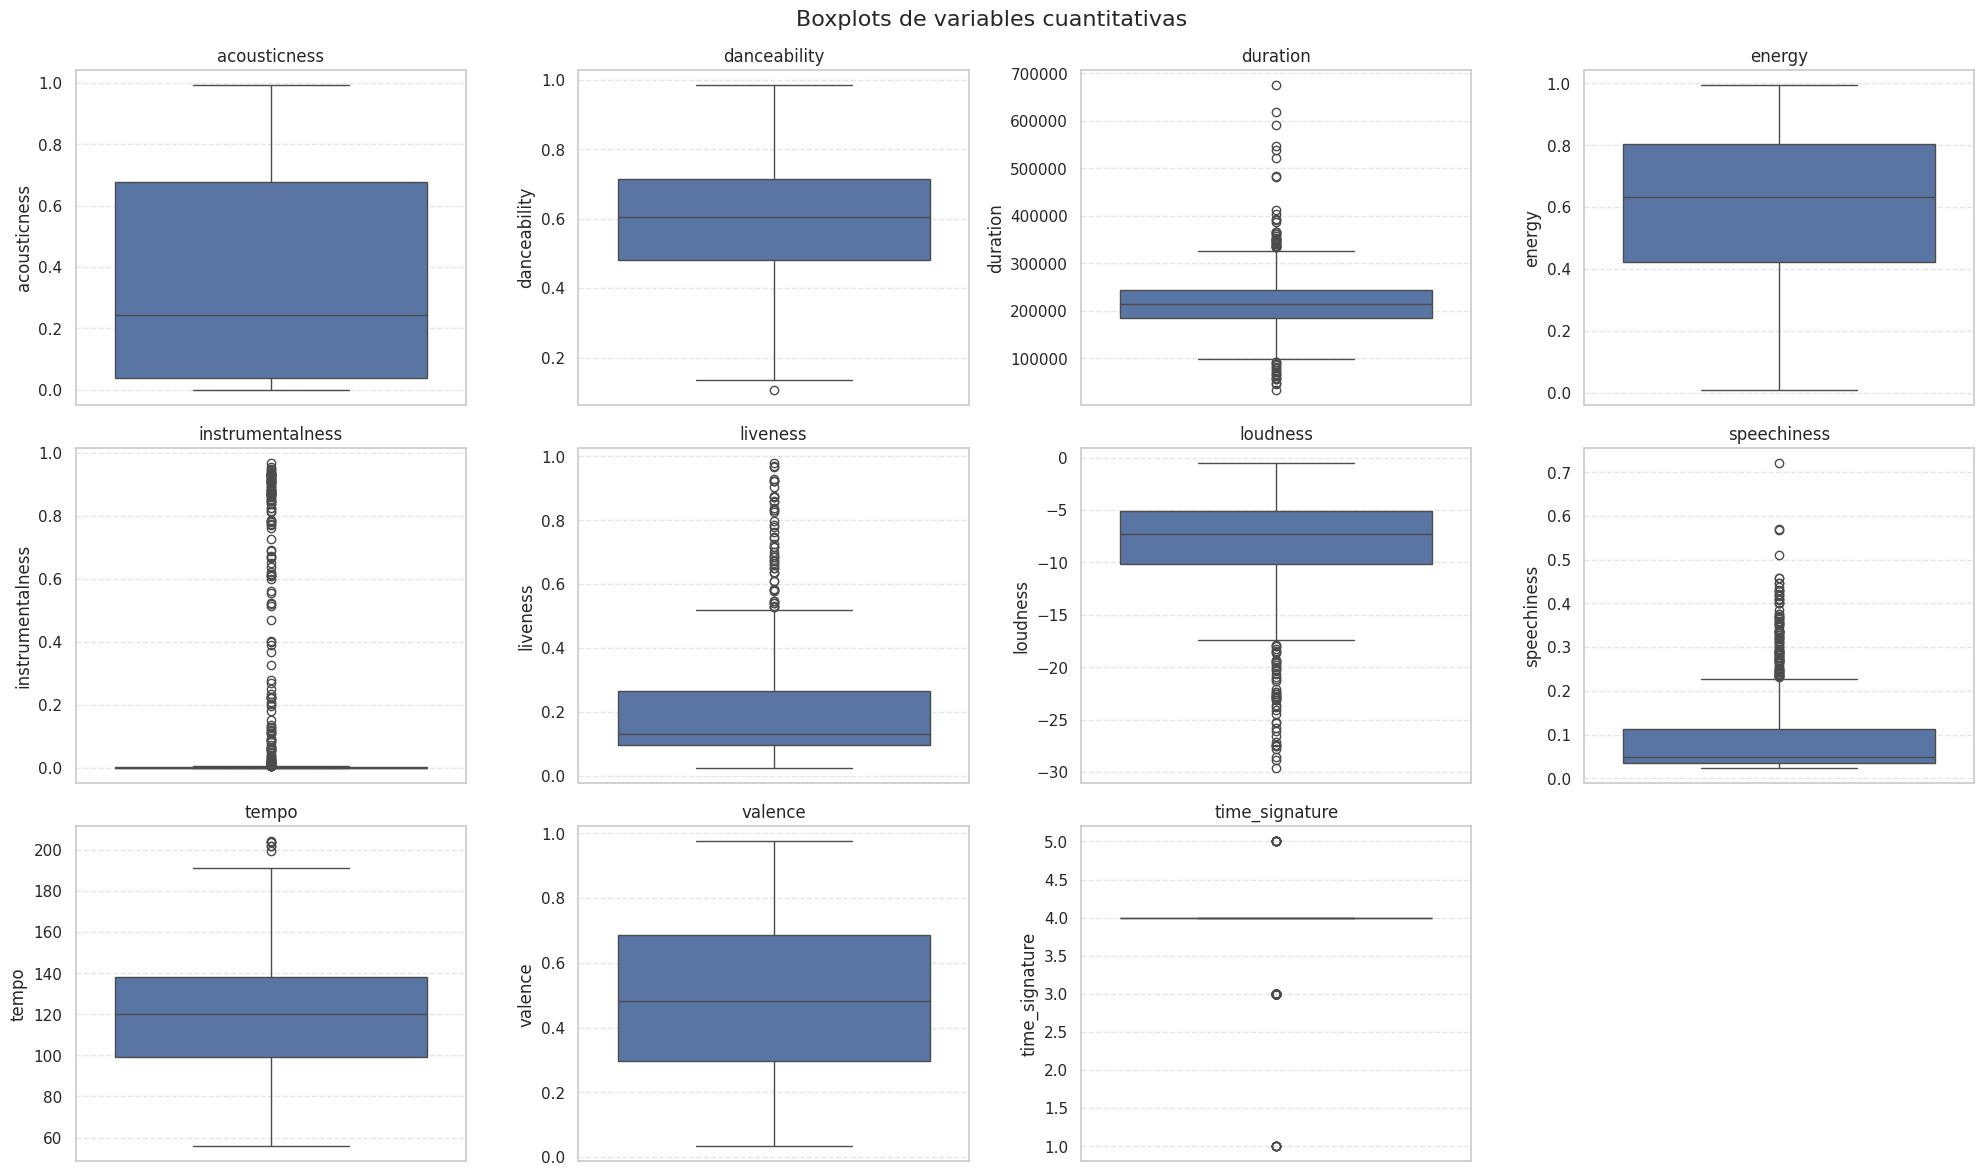

In [66]:
#Boxplots individuales por variable cuantitativa

n = len(variables_cuantitativas)
cols = 4  #cantidad de columnas que querés en el grid
rows = -(-n // cols)  #división entera hacia arriba

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables_cuantitativas ):
    sns.boxplot(data=data, y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots de variables cuantitativas', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

En general, observamos que no hay muchos valores atípicos en el Dataset, pues las variables **instrumentalness, liveness**, **speechiness** o **time_signature** pueden tener esos valores que se marcan como outliers en los gráficos. La única variable a la que podríamos llegar a cuestionar es a **duration**, pues hay pistas entre 400000 y 700000 ms, lo que equivale a 6.6667 minutos y a 11.6667 minutos respectivamente. Estos valores a simple vista pueden ser altos para canciones de Spotify, pero la realidad es que son totalmente válidos pues existen canciones que tienen esa duración.

Por lo tanto, optamos por no imputar ni filtrar valores atípicos.

Para explorar las relaciones entre las variables numéricas de nuestro dataset, vamos a generar un gráfico de pares.

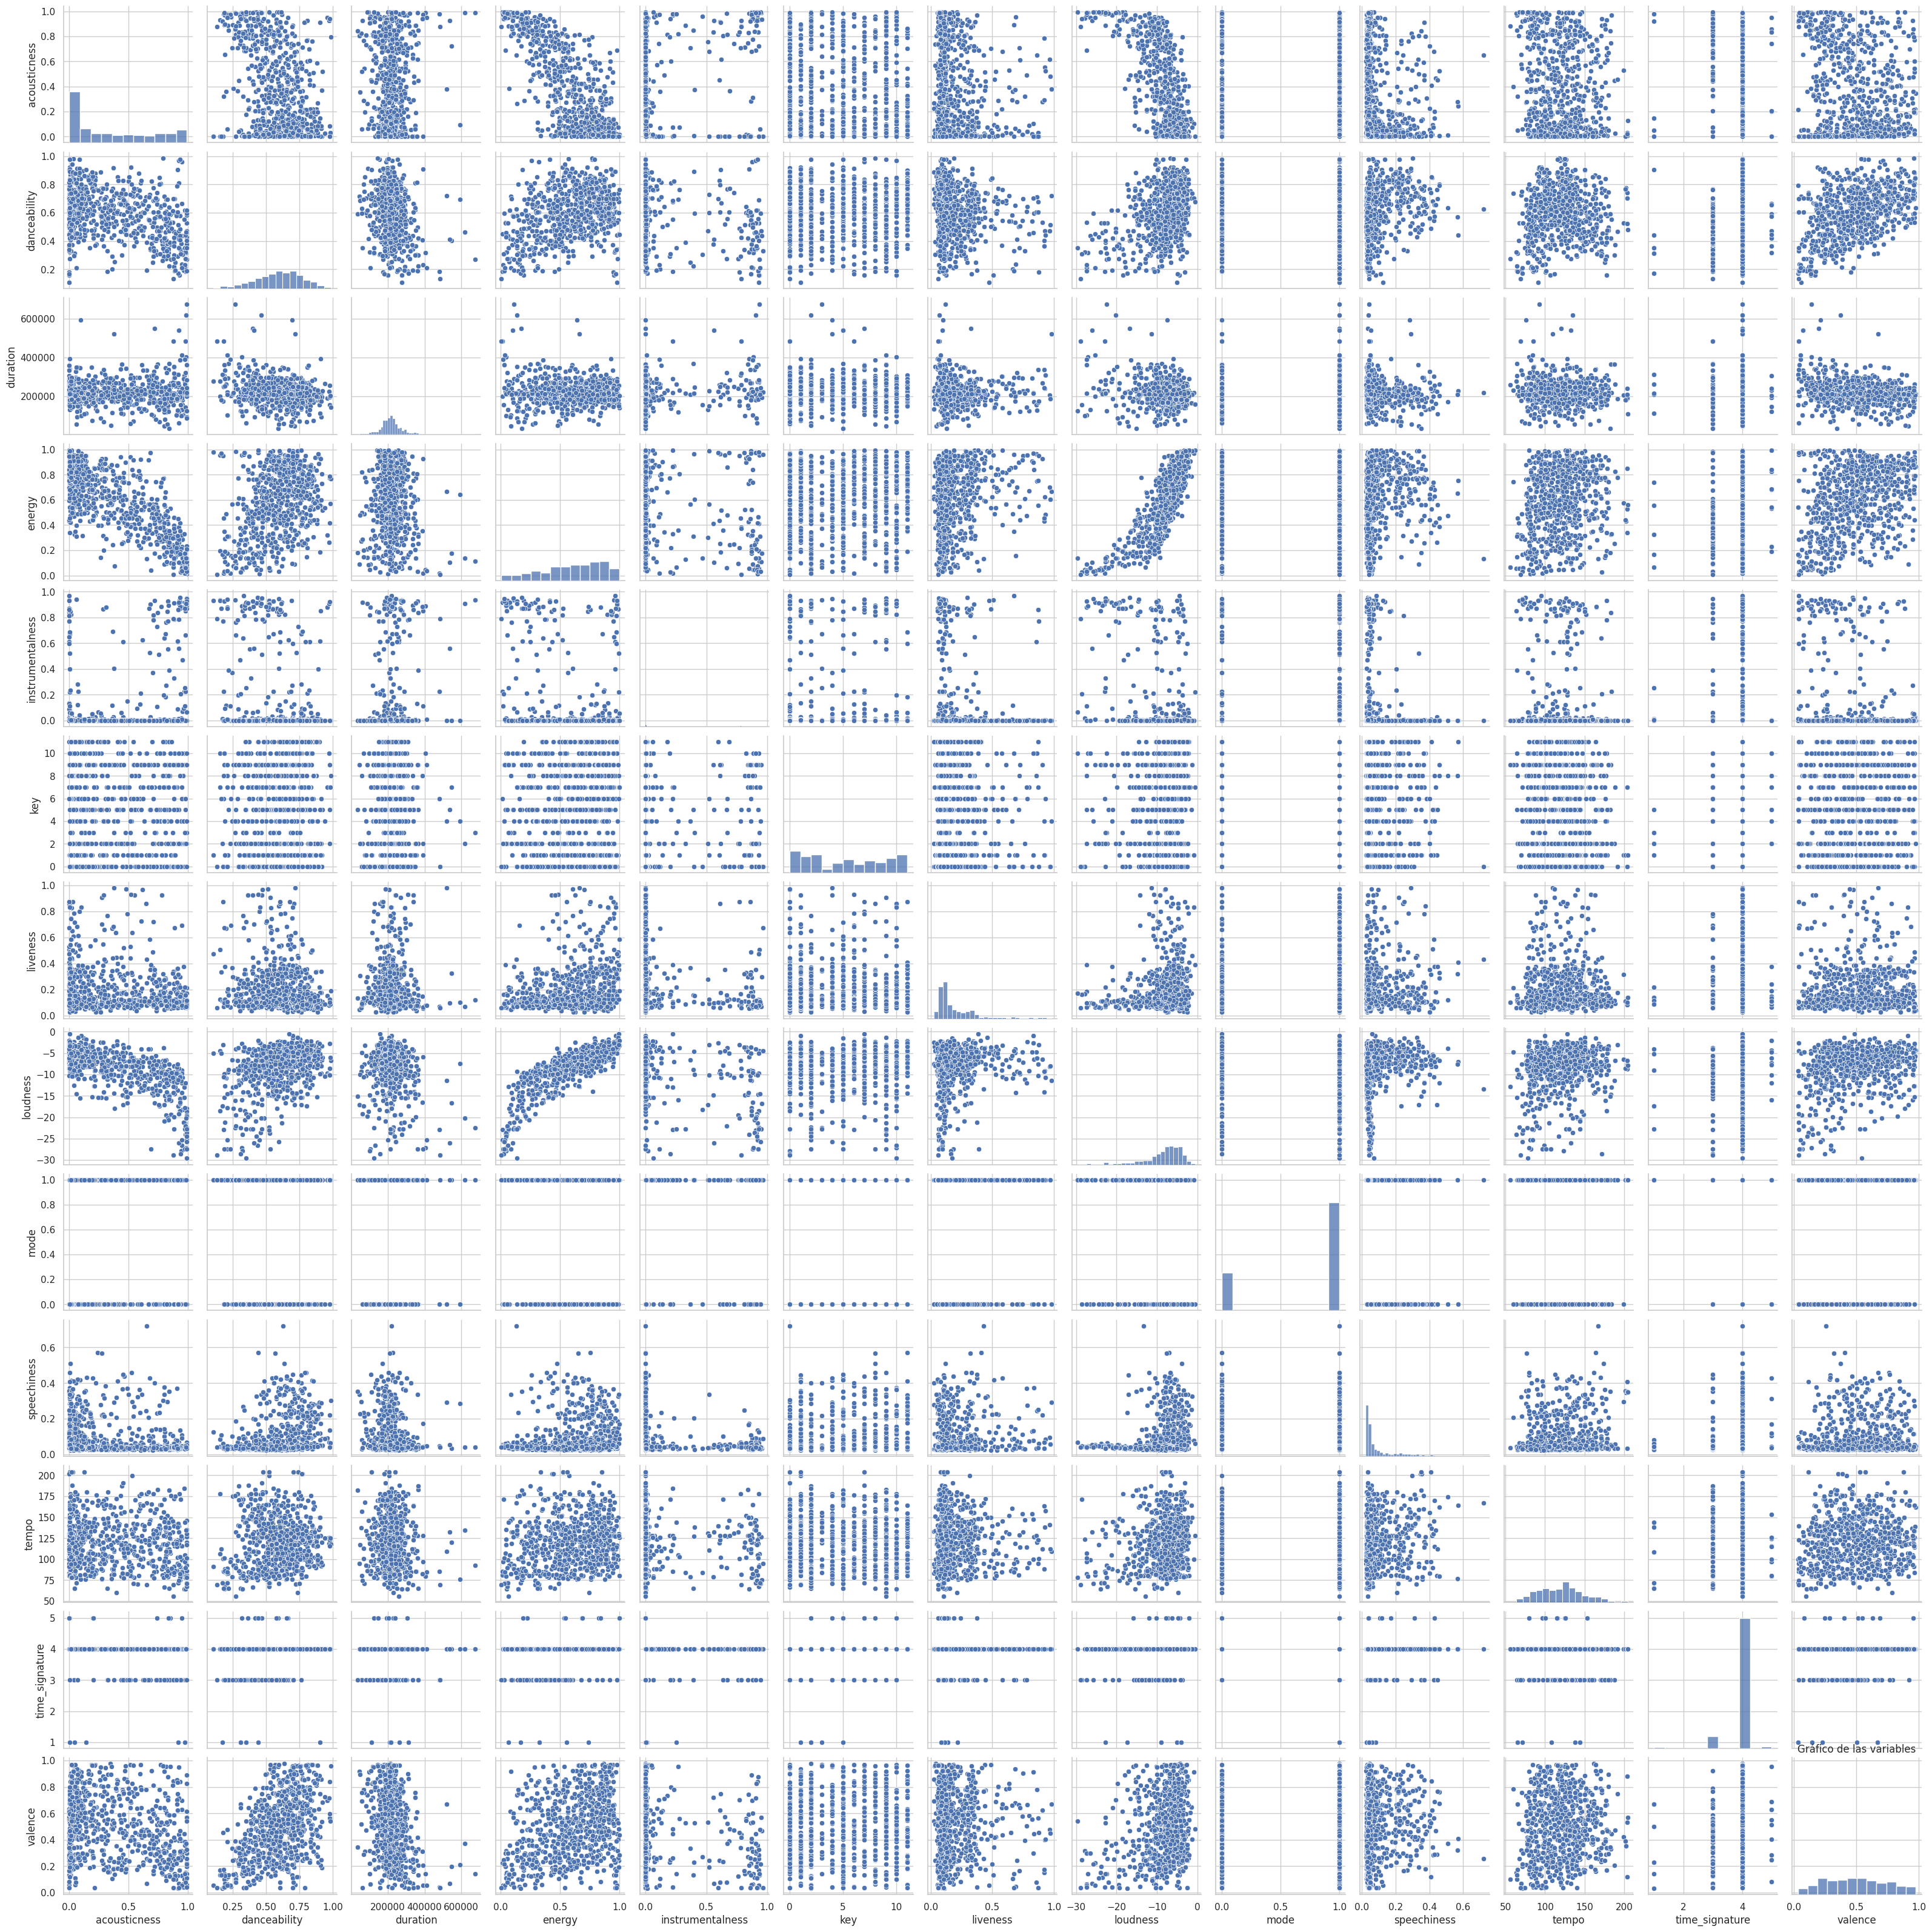

In [67]:
sns.pairplot(data)
plt.title("Gráfico de las variables")
plt.show()

## Análisis de la tendencia al clustering

 Calculemos el índice de Hopkins para evaluar la tendencia al clustering.

In [68]:
import numpy as np
import random
from sklearn.neighbors import NearestNeighbors

def Hopkins(datos, *args, random_state=None):
    if random_state is not None:
        random.seed(random_state)
        np.random.seed(random_state)

    n = datos.shape[0]
    d = datos.shape[1]

    if not args:
        m = int(0.1 * n)
        print("Número de puntos al azar por defecto:", m)
    else:
        m = args[0]

    nbrs = NearestNeighbors(n_neighbors=1, algorithm='brute').fit(datos)
    rand_ind = random.sample(range(0, n), m)

    ui = []
    wi = []

    for j in range(m):
        # Punto sintético dentro del rango del dataset
        punto_aleatorio = np.random.uniform(np.min(datos, axis=0), np.max(datos, axis=0)).reshape(1, -1)
        u_dist, _ = nbrs.kneighbors(punto_aleatorio, 2, return_distance=True)
        ui.append(u_dist[0][1])

        w_dist, _ = nbrs.kneighbors(datos[rand_ind[j]].reshape(1, -1), 2, return_distance=True)
        wi.append(w_dist[0][1])

    H = sum(ui) / (sum(ui) + sum(wi))
    return H

In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled_hop = scaler.fit_transform(data)

hopkins_score = Hopkins(data_scaled_hop, random_state=42)
print(f"Hopkins Statistic: {hopkins_score:.4f}")

Número de puntos al azar por defecto: 75
Hopkins Statistic: 0.7799


Un valor de Hopkins cercano a 1 (en nuestro caso 0.7939) sugiere que los datos están estructurados y probablemente sean adecuados para la agrupación en clústeres.

####Analicemos cómo se distribuyen visualente

Visualicemos los datos aplicando el algoritmo PCA (Análisis de Componentes Principales)

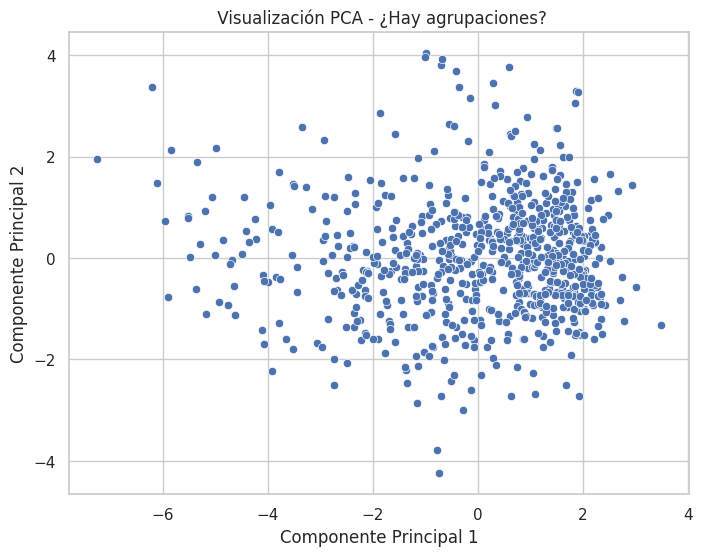

In [70]:
#Análisis de Componentes Principales --> Probamos con PCA para ver agrupaciones (lineal)

# Estandarizamos los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Visualización
plt.figure(figsize=(8,6))
sns.scatterplot(x=data_pca[:,0], y=data_pca[:,1])
plt.title(" Visualización PCA - ¿Hay agrupaciones?")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

Observando el gráfico con PCA, a simple vista no logramos inferir si hay agrupaciones y cómo estas están definidas, por lo que probaremos con el algoritmo t-SNE.

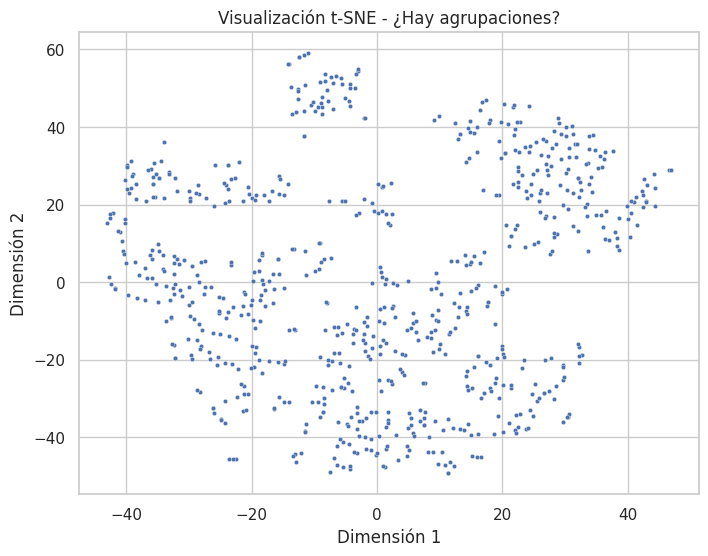

In [71]:
#Probamos con t-SNE t-Distributed Stochastic Neighbor Embedding (no lineal)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

#Pipeline de t-SNE sobre "data" (normalizamos!)
tsne = make_pipeline(StandardScaler(), TSNE(n_components=2, perplexity=15, random_state=42))
data_tsne = tsne.fit_transform(data)

#Visualización
plt.figure(figsize=(8,6))
sns.scatterplot(x=data_tsne[:,0], y=data_tsne[:,1], s=10)
plt.title("Visualización t-SNE - ¿Hay agrupaciones?")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()


Ahora sí se visualizan de forma más clara posibles agrupamientos. Aunque algunos se superponen, se percibe cierta estructura, lo que sugiere que K-Means podría identificar clusters significativos.

###¿Cómo elegimos el tamaño del Cluster?

###Método del Codo

Primero veamos el número óptimo de clústeres en los que se debe separar un conjunto de datos según el Método del Codo.

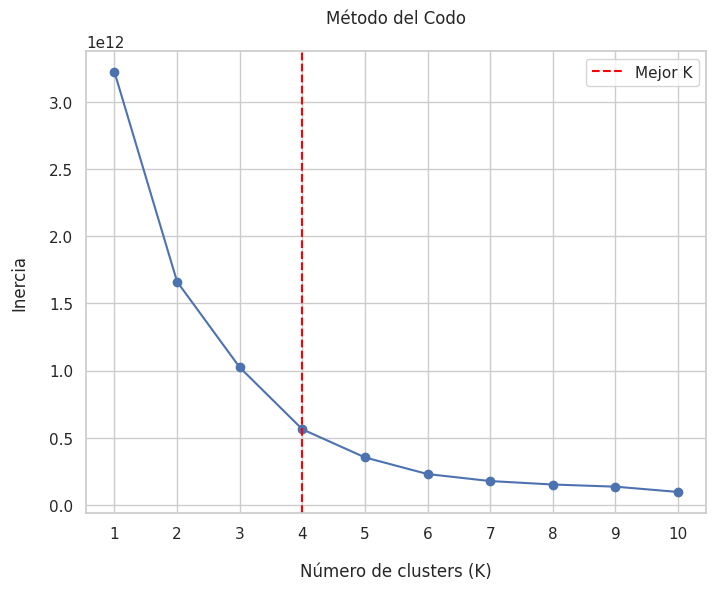

In [72]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

inercias = []  # medida de qué tan compactos son los clusters
k_range = range(1, 11)  # número de clusters a probar

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    inercias.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8, 6))
plt.plot(k_range, inercias, marker='o')
plt.title('Método del Codo', pad=20)
plt.xlabel('Número de clusters (K)', labelpad=15)
plt.ylabel('Inercia', labelpad=15)
plt.xticks(k_range)
plt.grid(True)

# Algoritmo para encontrar el "codo" (punto más alejado de la línea recta)
x = np.array(list(k_range))
y = np.array(inercias)

# Línea entre primer y último punto
p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])

# Distancia perpendicular de cada punto a la línea
def distancia(p, a, b):
    return np.abs(np.cross(b - a, a - p)) / np.linalg.norm(b - a)

distancias = [distancia(np.array([x[i], y[i]]), p1, p2) for i in range(len(x))]
best_k_index = np.argmax(distancias)
best_k = x[best_k_index]

# Dibujamos línea vertical en el mejor K
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Mejor K')
plt.legend()
plt.show()

 El mejor K según el método del codo es 4. Veamos como se agrupan los datos si cambiamos el valor k:

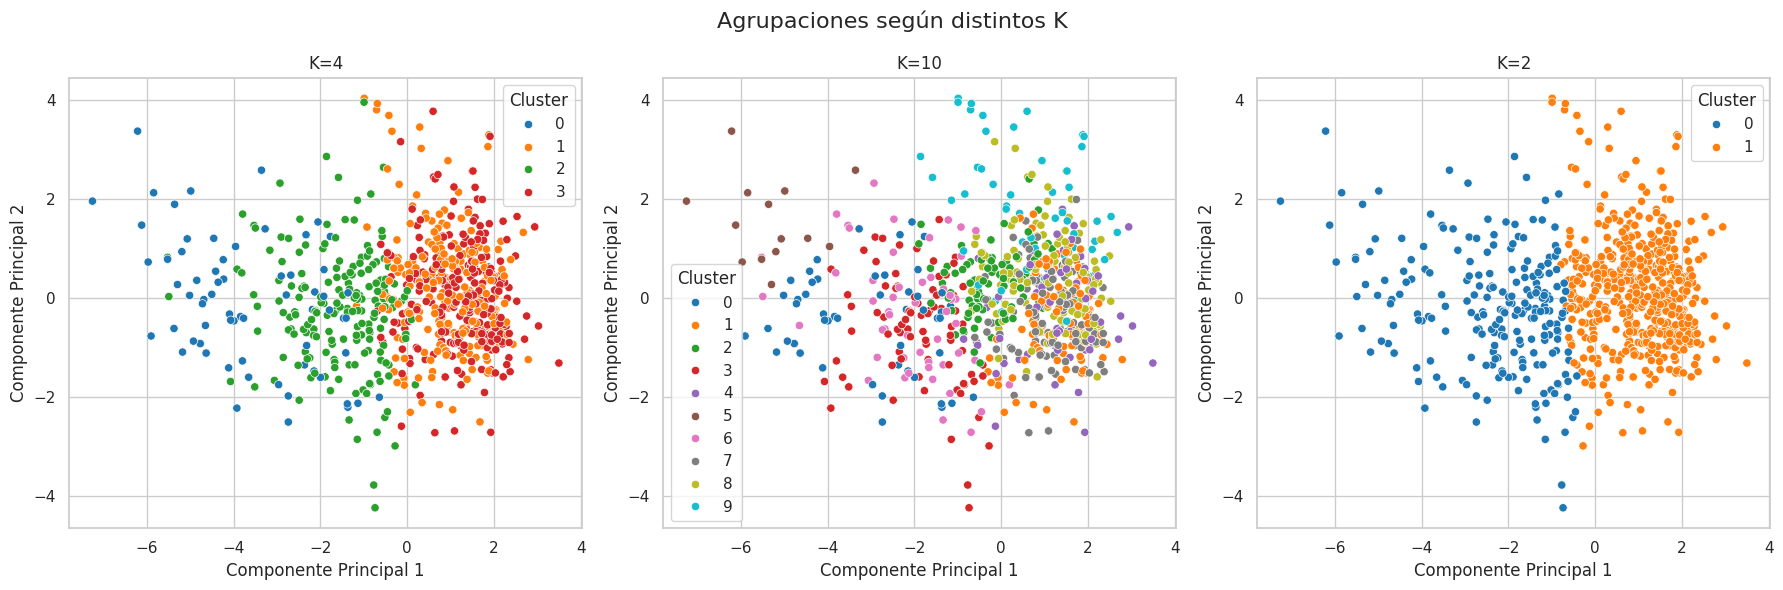

In [73]:
#Análisis de clustering con K-Means usando tres k distintos

#Aplicamos KMeans con K=4
kmeans1 = KMeans(n_clusters=4, random_state=42)
clusters1 = kmeans1.fit_predict(data_scaled)

#Aplicamos KMeans con K=10
kmeans2 = KMeans(n_clusters=10, random_state=42)
clusters2 = kmeans2.fit_predict(data_scaled)

#Aplicamos KMeans con K=2
kmeans3 = KMeans(n_clusters=2, random_state=42)
clusters3 = kmeans3.fit_predict(data_scaled)

#Agregamos los clusters como nueva columna para análisis posterior
data['cluster_k=4'] = clusters1
data['cluster_k=10'] = clusters2
data['cluster_k=2'] = clusters3

#Visualización con PCA (para ver en 2D)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

#Configuramos la figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 fila, 3 columnas, tamaño grande

#Primer gráfico: clusters1
sns.scatterplot(ax=axes[0], x=data_pca[:,0], y=data_pca[:,1], hue=clusters1, palette="tab10")
axes[0].set_title("K=4")
axes[0].set_xlabel("Componente Principal 1")
axes[0].set_ylabel("Componente Principal 2")
axes[0].legend(title="Cluster")

#Segundo gráfico: clusters2
sns.scatterplot(ax=axes[1], x=data_pca[:,0], y=data_pca[:,1], hue=clusters2, palette="tab10")
axes[1].set_title("K=10")
axes[1].set_xlabel("Componente Principal 1")
axes[1].set_ylabel("Componente Principal 2")
axes[1].legend(title="Cluster")

#Tercer gráfico: clusters3
sns.scatterplot(ax=axes[2], x=data_pca[:,0], y=data_pca[:,1], hue=clusters3, palette="tab10")
axes[2].set_title("K=2")
axes[2].set_xlabel("Componente Principal 1")
axes[2].set_ylabel("Componente Principal 2")
axes[2].legend(title="Cluster")

#Ajustamos bien los espacios
fig.suptitle("Agrupaciones según distintos K", fontsize=16)
plt.tight_layout()
plt.show()

 Aunque el método del codo sugiera K=4, podemos ver que K=2 es el que mejor se ajusta a la estructura real de los datos.

 Vemos que con K=10, a visualización muestra una dispersión confusa, sin una separación clara entre los clusters, lo que sugiere que este valor de K no es adecuado para representar adecuadamente las agrupaciones. Por lo tanto, eliminamos el cluster de K=10 del Dataset


In [74]:
data = data.drop(columns=['cluster_k=10'])

###Silhouette Score

A continuación, graficamos el Silhouette Score para diferentes valores de K (entre 2 y 11) con el objetivo de identificar el número óptimo de clusters según este criterio, y así compararlo con el método del codo.

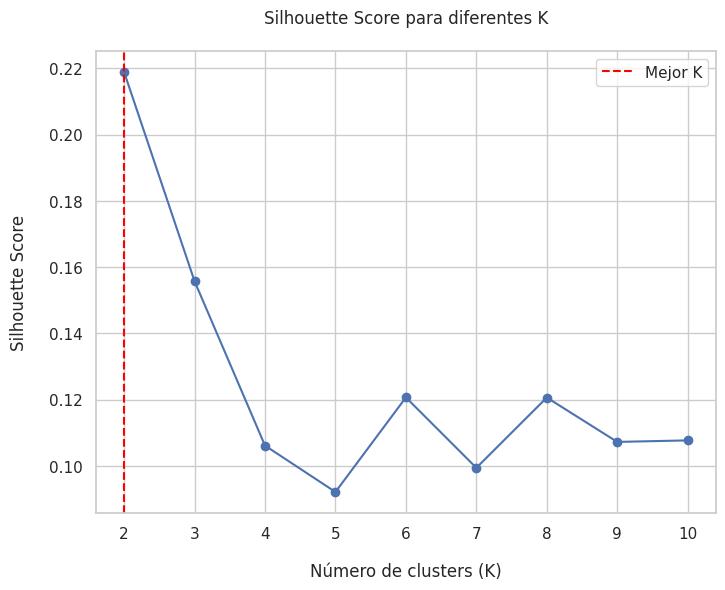



Para K = 2, el Silhouette Score es: 0.2189
Para K = 3, el Silhouette Score es: 0.1557
Para K = 4, el Silhouette Score es: 0.1061
Para K = 5, el Silhouette Score es: 0.0921
Para K = 6, el Silhouette Score es: 0.1206
Para K = 7, el Silhouette Score es: 0.0994
Para K = 8, el Silhouette Score es: 0.1206
Para K = 9, el Silhouette Score es: 0.1072
Para K = 10, el Silhouette Score es: 0.1077


In [75]:
# Evaluamos los distintos K usando Silhouette
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)

# Encontramos el mejor K
best_k_index = silhouette_scores.index(max(silhouette_scores))
best_k = k_values[best_k_index]

# Graficamos los resultados
plt.figure(figsize = (8, 6))
plt.plot(k_values, silhouette_scores, marker = 'o')
plt.axvline(x = best_k, color = 'red', linestyle = '--', label = f'Mejor K')  # Línea roja para el mejor K
plt.title('Silhouette Score para diferentes K', pad = 20)
plt.xlabel('Número de clusters (K)', labelpad = 15)
plt.ylabel('Silhouette Score', labelpad = 15)
plt.xticks(k_values)
plt.grid(True)
plt.legend()  # Agregar leyenda
plt.show()

print('\n')
# Mostramos los scores en consola
for i in range(len(k_values)):
    print(f"Para K = {k_values[i]}, el Silhouette Score es: {silhouette_scores[i]:.4f}")

Esto nos sugiere que el valor de K=2 es el más óptimo ya que maximiza el Silhouette Score, y por lo tanto, es el que indica la mejor separación y cohesión entre clusters según este criterio.  

##Exploración de las variables que distinguen los clusters

Observamos con t-SNE la representación (2D) de cada cluster

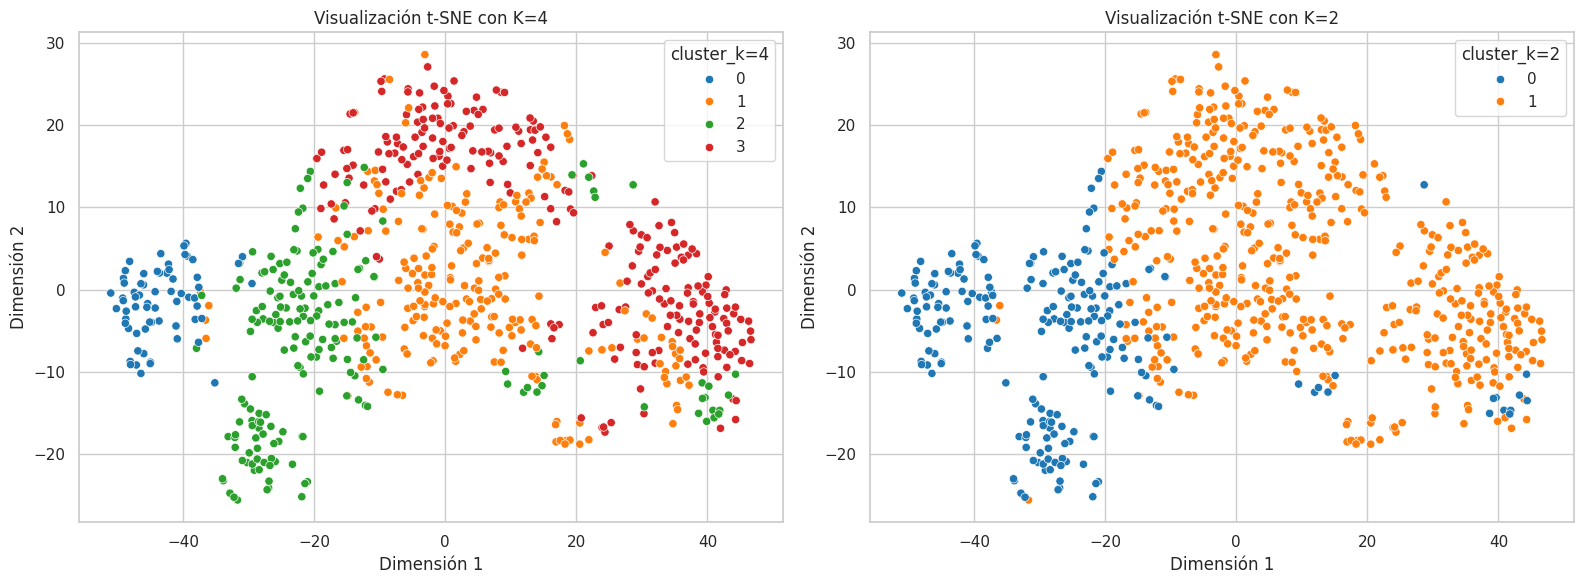

In [76]:
# Aplicamos t-SNE una sola vez
tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transform(data_scaled)

# Configuramos la figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graficamos K=4
sns.scatterplot(ax=axes[0], x=data_tsne[:, 0], y=data_tsne[:, 1], hue=data['cluster_k=4'], palette='tab10')
axes[0].set_title('Visualización t-SNE con K=4')
axes[0].set_xlabel('Dimensión 1')
axes[0].set_ylabel('Dimensión 2')
axes[0].grid(True)

# Graficamos K=2
sns.scatterplot(ax=axes[1], x=data_tsne[:, 0], y=data_tsne[:, 1], hue=data['cluster_k=2'], palette='tab10')
axes[1].set_title('Visualización t-SNE con K=2')
axes[1].set_xlabel('Dimensión 1')
axes[1].set_ylabel('Dimensión 2')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Podemos notar que con K=4 los agrupamientos no son evidentes y los colores utilizados para representar cada grupo tienden a mezclarse, lo que sugiere que la segmentación no es tan precisa. En cambio, con K=2 los grupos obtenidos presentan una separación clara, con fronteras bien definidas y una distribución adecuada de los datos. Por lo tanto, consideramos que el valor más óptimo de k es 2 ya que ofrece una mejor interpretación visual y estadística de los datos.


Para identificar las características predominantes en cada grupo, calculamos los valores promedio de las variables de las canciones agrupadas por los 2 clusters:

In [77]:
agrupacion_cluster_k_2 = data.groupby('cluster_k=2').mean()
agrupacion_cluster_k_2 = agrupacion_cluster_k_2.drop(columns=['cluster_k=4'])

print(tabulate(agrupacion_cluster_k_2, headers='keys', tablefmt='fancy_grid', showindex=True))

╒═══════════════╤════════════════╤════════════════╤════════════╤══════════╤════════════════════╤═════════╤════════════╤════════════╤══════════╤═══════════════╤═════════╤══════════════════╤═══════════╕
│   cluster_k=2 │   acousticness │   danceability │   duration │   energy │   instrumentalness │     key │   liveness │   loudness │     mode │   speechiness │   tempo │   time_signature │   valence │
╞═══════════════╪════════════════╪════════════════╪════════════╪══════════╪════════════════════╪═════════╪════════════╪════════════╪══════════╪═══════════════╪═════════╪══════════════════╪═══════════╡
│             0 │       0.759425 │       0.466929 │     232094 │ 0.29864  │           0.247272 │ 4.36444 │   0.154536 │  -13.6362  │ 0.826667 │     0.0500853 │ 112.451 │          3.69778 │  0.366999 │
├───────────────┼────────────────┼────────────────┼────────────┼──────────┼────────────────────┼─────────┼────────────┼────────────┼──────────┼───────────────┼─────────┼──────────────────┼────────

Grafiquemos estos valores para observar mejor como varían según el cluster al que pertenecen

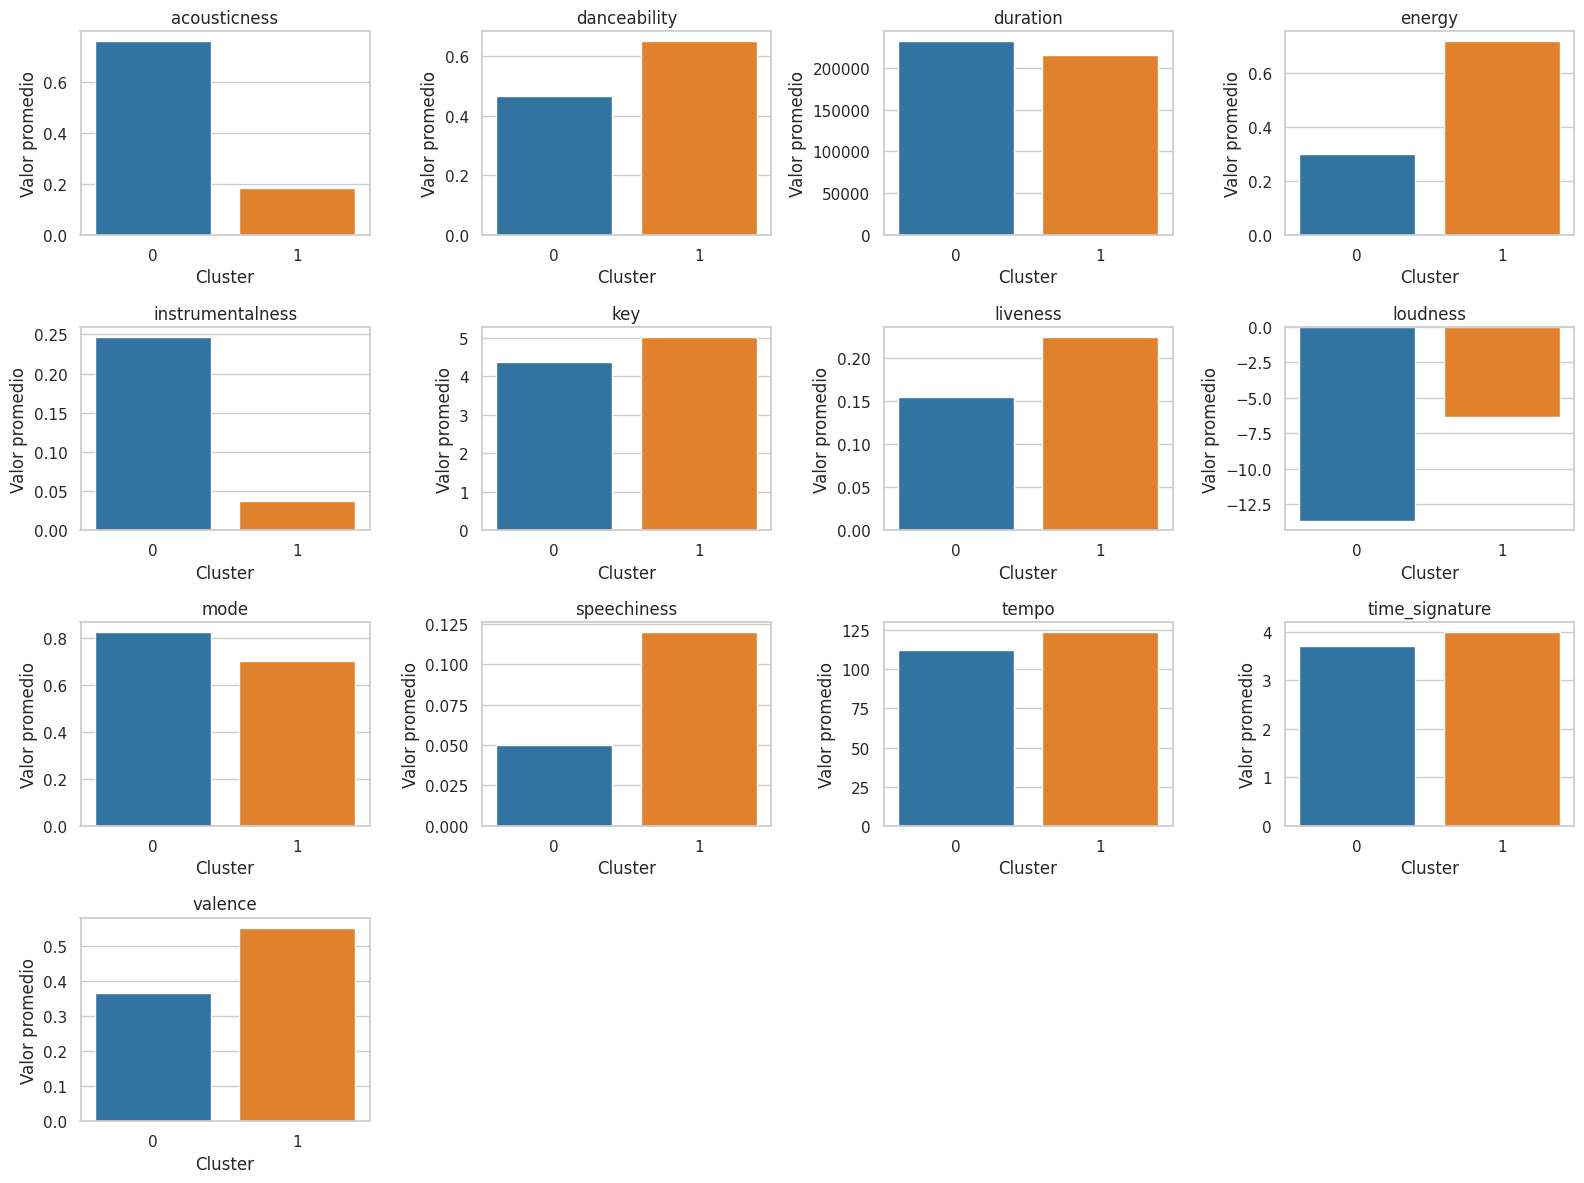

In [78]:
import math

variables = agrupacion_cluster_k_2.columns
num_cols = 4
num_rows = math.ceil(len(variables) / num_cols)

# Ajustar tamaño de la figura para que los gráficos no sean demasiado grandes
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, num_rows * 3))
axes = axes.flatten()

# Graficar
for i, variable in enumerate(variables):
    sns.barplot(x=agrupacion_cluster_k_2.index, y=agrupacion_cluster_k_2[variable], ax=axes[i], palette=["#1f77b4", "#ff7f0e"])
    axes[i].set_title(variable)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Valor promedio")

# Ocultar ejes vacíos si es necesario
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Analizando los datos y los gráficos, podemos identificar que los clusters de agrupan de la siguiente manera:

**Cluster 0**: Este conjunto tiene una alta acústica (acousticness) e instrumentalness, lo que indica una mayor cantidad de pistas sin voces o con sonidos más suaves. También muestra baja energía, menor danceability y un volumen (loudness) más bajo, sugiriendo que son canciones más tranquilas, posiblemente baladas, música clásica o acústica.

**Cluster 1**: Este grupo presenta mayor energía, danceability más alta y loudness elevado, lo que sugiere canciones más animadas, ideales para el baile. La speechiness también es más alta, indicando que puede haber más contenido hablado, como rap o música con muchos versos hablados. Además, el valence más alto sugiere que estas pistas tienden a transmitir emociones más positivas